<a href="https://colab.research.google.com/github/dorian-goueytes/M1_tronc_commun_stat/blob/main/Kmean_impulsivit%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import matplotlib as mpl



## Helper function

In [33]:
def plot_cov_ellipsoid(ax, mean, cov, color='blue', alpha=0.2, scale=2.0):
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)

    # Sort eigenvalues/vectors (largest first)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    # Radii (scale controls size, like confidence level)
    radii = scale * np.sqrt(eigvals)

    # Parametric sphere
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 30)

    x = np.outer(np.cos(u), np.sin(v))
    y = np.outer(np.sin(u), np.sin(v))
    z = np.outer(np.ones_like(u), np.cos(v))

    # Stack coordinates
    sphere = np.stack((x, y, z), axis=0).reshape(3, -1)

    # Transform sphere → ellipsoid
    ellipsoid = eigvecs @ np.diag(radii) @ sphere
    ellipsoid = ellipsoid.reshape(3, x.shape[0], x.shape[1])

    # Translate to mean
    x_e = ellipsoid[0] + mean[0]
    y_e = ellipsoid[1] + mean[1]
    z_e = ellipsoid[2] + mean[2]

    ax.plot_surface(x_e, y_e, z_e, color=color, alpha=alpha, linewidth=0)

## Loading raw data and computing scores

In [3]:
data = pd.read_csv("data.csv", sep = ';')

scores = pd.DataFrame(columns=['main_score', 'attention', 'motor', 'nonplanning', 'Q1', 'Q2'])#,'attention','motorC','self_control','sog_comp','perseverance','cog_insta'])
for part in range(0, np.shape(data)[0]):
  main_score, attention,motor,nonplanning = 0,0,0,0
  for item in range(0, np.shape(data)[1]):
    ## Attention
    if item in np.array([5,6,9,11,20,24,26,28])-1: #attention
      if item in np.array([9,20])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          attention +=4
        if data.to_numpy()[part][item] == "Occasionally":
          attention +=3
        if data.to_numpy()[part][item] == "Often":
          attention +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          attention +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          attention +=1
        if data.to_numpy()[part][item] == "Occasionally":
          attention +=2
        if data.to_numpy()[part][item] == "Often":
          attention +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          attention +=4
    ## motor
    if item in np.array([2,3,4,17,19,22,25,16,21,23,30])-1:
      if item in np.array([30])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          motor +=4
        if data.to_numpy()[part][item] == "Occasionally":
          motor +=3
        if data.to_numpy()[part][item] == "Often":
          motor +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          motor +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          motor +=1
        if data.to_numpy()[part][item] == "Occasionally":
          motor +=2
        if data.to_numpy()[part][item] == "Often":
          motor +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          motor +=4

    ## nonplanning
    if item in np.array([1,7,8,12,13,14,10,15,18,27,29])-1:
      if item in np.array([1,7,8,12,13,10,15,29])-1:# reversal
        if data.to_numpy()[part][item] == "Rarely/Never":
          nonplanning +=4
        if data.to_numpy()[part][item] == "Occasionally":
          nonplanning +=3
        if data.to_numpy()[part][item] == "Often":
          nonplanning +=2
        if data.to_numpy()[part][item] == "Almost Always/Always":
          nonplanning +=1
      else:
        if data.to_numpy()[part][item] == "Rarely/Never":
          nonplanning +=1
        if data.to_numpy()[part][item] == "Occasionally":
          nonplanning +=2
        if data.to_numpy()[part][item] == "Often":
          nonplanning +=3
        if data.to_numpy()[part][item] == "Almost Always/Always":
          nonplanning +=4

    ### Main score
    if data.to_numpy()[part][item] == "Rarely/Never":
      main_score +=1
    if data.to_numpy()[part][item] == "Occasionally":
      main_score +=2
    if data.to_numpy()[part][item] == "Often":
      main_score +=3
    if data.to_numpy()[part][item] == "Almost Always/Always":
      main_score +=4

    if item == 30:
      if data.to_numpy()[part][item] == "Obtenir un paquet de chocolats à la fin du cours d'aujourd'hui":
        Q1 = 1
      else:
        Q1 = -1
    if item == 31:
      if data.to_numpy()[part][item] == "Obtenir un paquet de chocolats dans 12 mois":
        Q2 = 1
      else:
        Q2 = -1

  scores.loc[part] = [main_score, attention, motor, nonplanning, Q1, Q2]

    main_score  attention  motor  nonplanning  Q1  Q2
0           77         27     24           29  -1  -1
1           82         16     26           25   1   1
2           69         31     21           28  -1  -1
3           69         16     13           13   1  -1
4           60         16     15           22   1  -1
..         ...        ...    ...          ...  ..  ..
95          67         11     26           17   1  -1
96          80         19     20           19   1  -1
97          71         20     30           20   1  -1
98          48         13     17           23   1   1
99          60         18     13           17   1  -1

[100 rows x 6 columns]


## K-mean

### Visualization of raw data

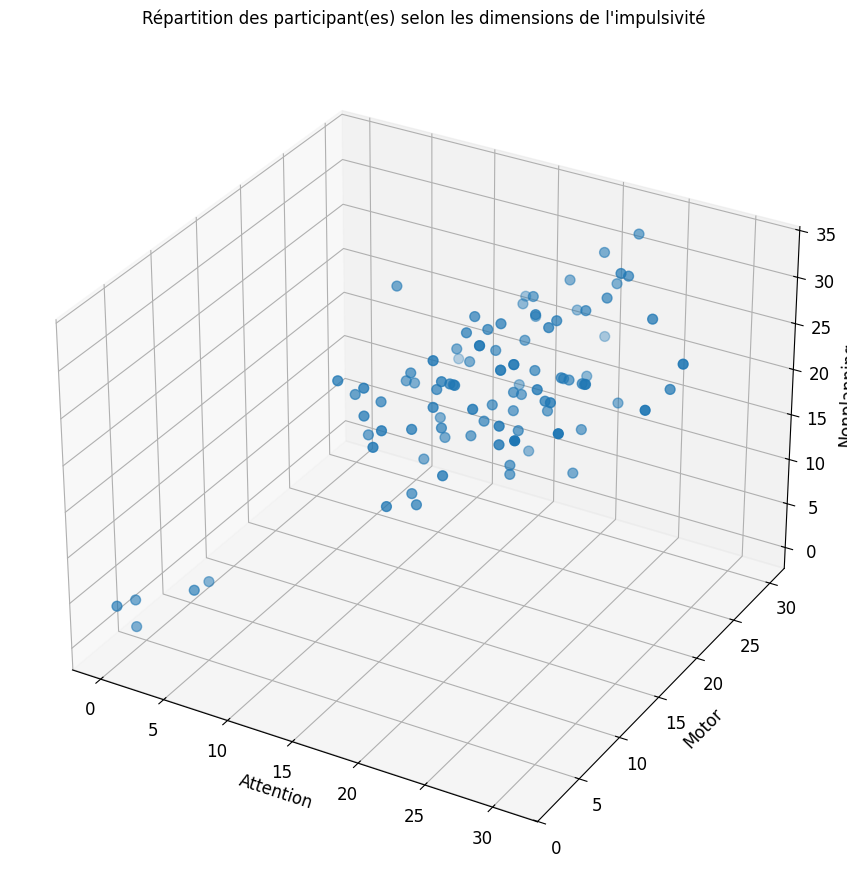

In [6]:
fig = plt.figure(figsize=(9, 9))
plt.suptitle("Répartition des participant(es) selon les dimensions de l'impulsivité")
plt.rcParams.update({'font.size': 12})
ax = fig.add_subplot(projection='3d')
ax.scatter(scores['attention'], scores['motor'], scores['nonplanning'], s =  50)
ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
plt.tight_layout()
plt.show()

### K-mean and visualization

Helper function

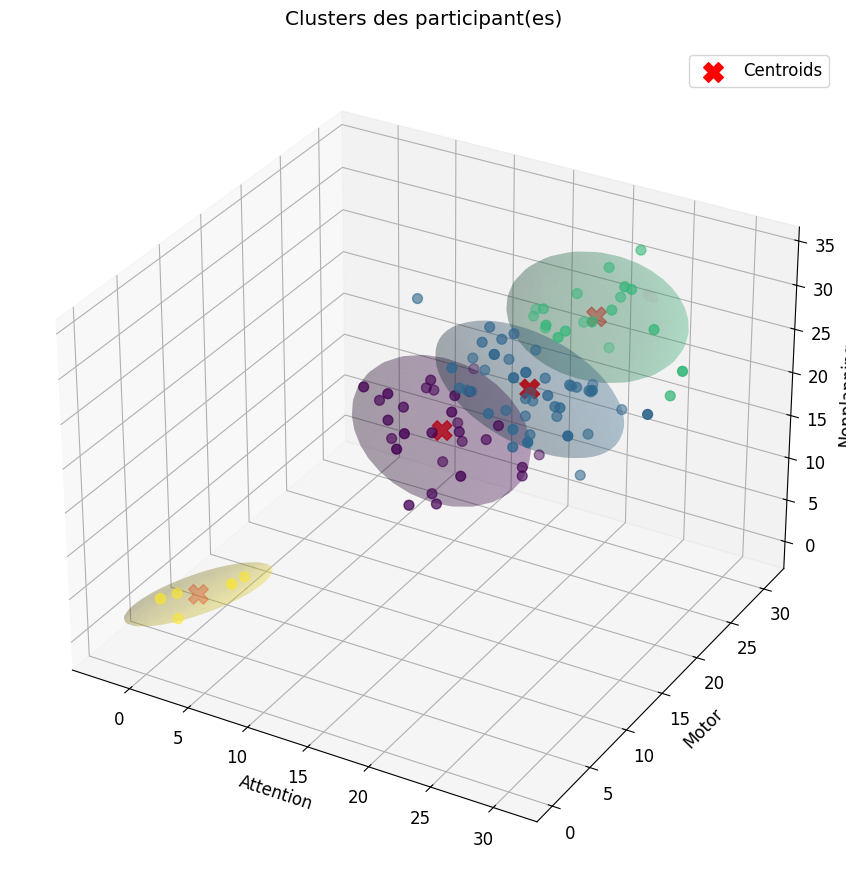

In [41]:
X  = scores[['attention', 'motor', 'nonplanning']].to_numpy()

#############################################
##### K-means and plot
n_cluster = 4 # @param {type:"slider", min:2, max:10, step:1}
kmeans = KMeans(n_clusters=n_cluster, random_state=0, n_init="auto").fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot clustered data
fig = plt.figure(figsize=(9, 9))
plt.suptitle("Clusters des participant(es)")
ax = fig.add_subplot(projection='3d')
scatter = ax.scatter(X[:, 0], X[:, 1], X[:, 2],c=labels,  cmap='viridis',s=50)
# Plot centroids
ax.scatter(centers[:, 0], centers[:, 1], centers[:, 2],c='red', s=200, marker='X', label='Centroids')



# Plot ellipsoids
cmap = mpl.colormaps['viridis']
colors = cmap(np.linspace(0, 1,n_cluster))

for i in range(kmeans.n_clusters):
    cluster_points = X[labels == i]
    mean = centers[i]
    cov = np.cov(cluster_points, rowvar=False)
    plot_cov_ellipsoid(ax, mean, cov, color=colors[i], scale=2.0)


ax.set_xlabel('Attention')
ax.set_ylabel('Motor')
ax.set_zlabel('Nonplanning')
ax.legend()

#ax.view_init(azim=180, elev=20)

plt.tight_layout()
plt.show()
